# 01 — Análise inicial dos datasets MCQ

**Extensão para journal** do paper *"Leveraging LLM Reflection to Improve Small Language Model Agents' Capabilities"* (AGENTICS 2025).

**Objetivo deste notebook:** antes de rodar qualquer modelo, caracterizar os datasets para tomar decisões iniciais e de longo prazo:

1. Ler e unificar os datasets (`data/mcq/`, schema: `id, question, choices{label,text}, answerKey`);
2. Quantificar splits de treino/validação/teste e apontar problemas de split;
3. Estatísticas textuais: comprimento, vocabulário, diversidade lexical, densidade numérica;
4. Semelhança entre perguntas: clusters (t-SNE), similaridade intra/inter-dataset;
5. **Viabilidade da recuperação treino→teste** (proxy da *Transferability* da Fase 3);
6. Análise do impacto esperado da reflexão em cada dataset (hipótese central: reflexão ajuda em erros de *processo*, pouco em erros de *conhecimento*);
7. Rotas e decisões (curto e longo prazo).

> Contexto completo: `../../CONTEXTO_extensao_journal.md`. Dados: `scripts/download_datasets.py`.

In [1]:
import re, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)

DATA = Path("..") / "data" / "mcq"
RESULTS = Path("..") / "results"
RESULTS.mkdir(exist_ok=True)
assert DATA.exists(), f"Dados não encontrados em {DATA.resolve()} — rode scripts/download_datasets.py"
print("Pasta de dados:", DATA.resolve())

Pasta de dados: C:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\eagle\journal_extension\data\mcq


## 1. Carregamento e unificação

Usamos `oil_and_gas_v2` (versão auditada, com `subject`/`difficulty`) e descartamos a v1. O split é inferido pelo nome do arquivo.

In [2]:
FILES = {
    "agieval_lsat": ["agievalar/dev.parquet", "agievalar/test.parquet"],
    "aqua":         ["aqua/train.parquet", "aqua/validation.parquet", "aqua/test.parquet"],
    "arc":          ["arc/arc_train.parquet", "arc/arc_validation.parquet", "arc/arc_test.parquet"],
    "gsm8k":        ["gsm8k/train.parquet", "gsm8k/test.parquet"],
    "mmlu":         ["mmlu/validation.parquet", "mmlu/test.parquet"],
    "oil_and_gas":  ["oil_and_gas_v2/test.parquet"],
}

def infer_split(fname: str) -> str:
    for s in ("train", "validation", "dev", "test"):
        if s in fname:
            return {"dev": "validation"}.get(s, s)
    return "unknown"

frames = []
for ds, paths in FILES.items():
    for p in paths:
        df = pd.read_parquet(DATA / p)
        df["dataset"], df["split"] = ds, infer_split(Path(p).name)
        df["n_choices"] = df["choices"].apply(lambda c: len(c["text"]))
        frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
print(f"{len(all_df):,} questões no total")
all_df.head(2)

124,238 questões no total


,id,question,choices,answerKey,dataset,split,n_choices,subject,justification,difficulty
0,agieval_ar_dev_0,A soloist will play six different guitar conce...,"{'label': ['A', 'B', 'C', 'D', 'E'], 'text': [...",E,agieval_lsat,validation,5,NaN,NaN,NaN
1,agieval_ar_dev_1,A six-week literature course is being planned ...,"{'label': ['A', 'B', 'C', 'D', 'E'], 'text': [...",A,agieval_lsat,validation,5,NaN,NaN,NaN


In [3]:
overview = (all_df.pivot_table(index="dataset", columns="split", values="id",
                               aggfunc="count", fill_value=0)
            .reindex(columns=["train", "validation", "test"], fill_value=0))
overview["total"] = overview.sum(axis=1)
overview["n_choices (moda)"] = all_df.groupby("dataset")["n_choices"].agg(lambda s: s.mode()[0])
overview

split,train,validation,test,total,n_choices (moda)
dataset,,,,,
agieval_lsat,0,3,230,233,5
aqua,97467,254,254,97975,5
arc,1119,299,1172,2590,4
gsm8k,7473,0,1319,8792,4
mmlu,0,70,12032,12102,10
oil_and_gas,0,0,2546,2546,4


In [4]:
# Distribuição do gabarito por posição (viés posicional importa: o feedback
# "incorreto" elimina uma alternativa — parte do ganho do retry vem daí)
gab = (all_df.groupby(["dataset", "answerKey"]).size().unstack(fill_value=0))
gab_pct = gab.div(gab.sum(axis=1), axis=0).round(3)
gab_pct

answerKey,1,2,3,4,A,B,C,D,E,F,G,H,I,J
dataset,,,,,,,,,,,,,,
agieval_lsat,0.000,0.000,0.000,0.000,0.232,0.176,0.202,0.193,0.197,0.000,0.000,0.000,0.000,0.000
aqua,0.000,0.000,0.000,0.000,0.211,0.220,0.228,0.199,0.141,0.000,0.000,0.000,0.000,0.000
arc,0.004,0.005,0.004,0.005,0.215,0.257,0.258,0.250,0.000,0.000,0.000,0.000,0.000,0.000
gsm8k,0.000,0.000,0.000,0.000,0.255,0.248,0.256,0.241,0.000,0.000,0.000,0.000,0.000,0.000
mmlu,0.000,0.000,0.000,0.000,0.117,0.112,0.109,0.111,0.096,0.094,0.098,0.093,0.092,0.079
oil_and_gas,0.000,0.000,0.000,0.000,0.124,0.431,0.421,0.024,0.000,0.000,0.000,0.000,0.000,0.000


**Problemas de split identificados (importantes para o desenho experimental):**

- `agieval_lsat`: apenas 3 questões de "dev" + 230 de teste → **não há pool de treino**; será preciso particionar o teste.
- `mmlu`: 70 de validação vs. 12.032 de teste → pool de treino minúsculo; particionar o teste.
- `oil_and_gas`: só teste (2.546) → particionar internamente (estratificando por `subject`).
- `aqua`: treino gigante (97.467) → subamostrar por custo.
- `gsm8k`: originalmente é resposta aberta; a versão aqui foi **convertida para MCQ** com distratores — precisamos documentar/verificar como os distratores foram gerados (alguns são implausíveis por ordem de magnitude, o que facilita eliminação).

## 2. Estatísticas textuais

Vocabulário e TTR (type-token ratio) dependem do tamanho do corpus, então além dos valores no corpus completo calculamos versões **normalizadas em amostras de 200 questões** por dataset (comparáveis entre si). A **densidade numérica** (fração de tokens que são números) é um proxy de raciocínio procedural/matemático.

In [5]:
TOKEN_RE = re.compile(r"[A-Za-z]+|\d+(?:[.,]\d+)?")
NUM_RE = re.compile(r"^\d")

def tokens(text):
    return [t.lower() for t in TOKEN_RE.findall(str(text))]

all_df["q_tokens"] = all_df["question"].apply(tokens)
all_df["q_len"] = all_df["q_tokens"].apply(len)
all_df["num_density"] = all_df["q_tokens"].apply(
    lambda ts: sum(bool(NUM_RE.match(t)) for t in ts) / max(len(ts), 1))
all_df["choices_len"] = all_df["choices"].apply(
    lambda c: np.mean([len(tokens(t)) for t in c["text"]]))

rows = []
for ds, g in all_df.groupby("dataset"):
    full_vocab = set().union(*g["q_tokens"])
    samp = g.sample(min(200, len(g)), random_state=42)
    toks = [t for ts in samp["q_tokens"] for t in ts]
    rows.append({
        "dataset": ds,
        "questões": len(g),
        "palavras/questão (média)": g["q_len"].mean(),
        "palavras/questão (mediana)": g["q_len"].median(),
        "palavras/alternativa": g["choices_len"].mean(),
        "vocab (corpus completo)": len(full_vocab),
        "vocab (amostra 200q)": len(set(toks)),
        "TTR (amostra 200q)": len(set(toks)) / len(toks),
        "densidade numérica": g["num_density"].mean(),
    })
text_stats = pd.DataFrame(rows).set_index("dataset").round(3)
text_stats

,questões,palavras/questão (média),palavras/questão (mediana),palavras/alternativa,vocab (corpus completo),vocab (amostra 200q),TTR (amostra 200q),densidade numérica
dataset,,,,,,,,
agieval_lsat,233,122.459,122.0,6.689,836,825,0.034,0.016
aqua,97975,33.218,31.0,1.596,21726,1313,0.197,0.127
arc,2590,22.485,19.0,4.979,5305,1321,0.296,0.006
gsm8k,8792,45.907,43.0,1.005,13046,1729,0.188,0.078
mmlu,12102,47.031,30.0,6.583,27753,2501,0.294,0.063
oil_and_gas,2546,10.372,10.0,5.307,2814,664,0.318,0.004


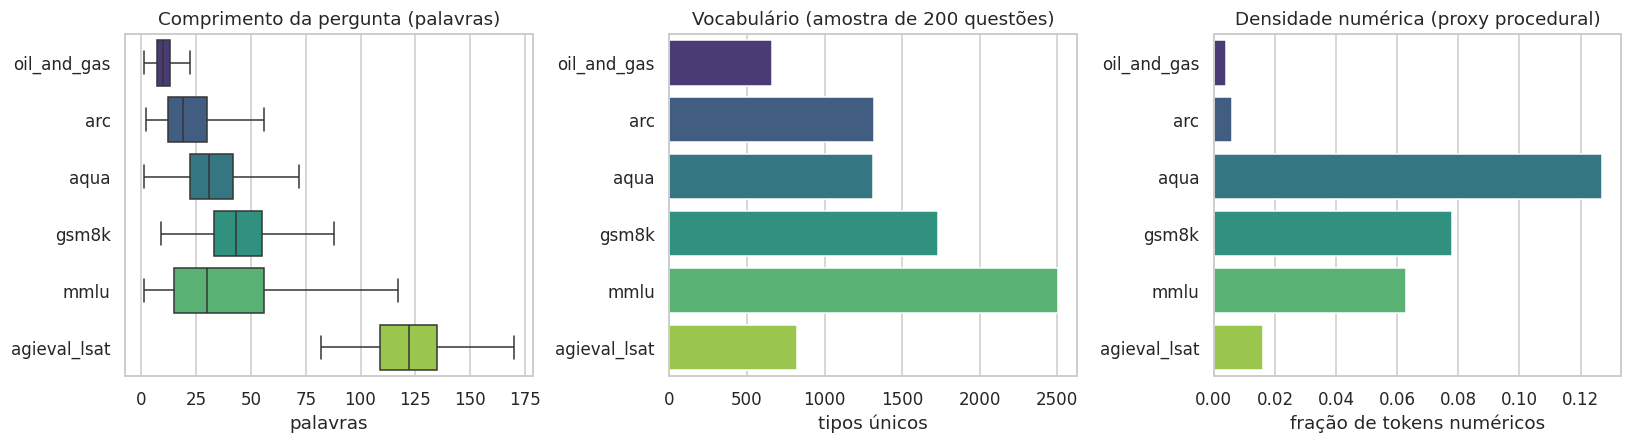

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
order = text_stats.sort_values("palavras/questão (média)").index

sns.boxplot(data=all_df, x="q_len", y="dataset", order=order, ax=axes[0],
            showfliers=False, palette="viridis")
axes[0].set(title="Comprimento da pergunta (palavras)", xlabel="palavras", ylabel="")

sns.barplot(x=text_stats.loc[order, "vocab (amostra 200q)"], y=order, ax=axes[1], palette="viridis")
axes[1].set(title="Vocabulário (amostra de 200 questões)", xlabel="tipos únicos", ylabel="")

sns.barplot(x=text_stats.loc[order, "densidade numérica"], y=order, ax=axes[2], palette="viridis")
axes[2].set(title="Densidade numérica (proxy procedural)", xlabel="fração de tokens numéricos", ylabel="")
plt.tight_layout(); plt.show()

## 3. Sobreposição de vocabulário entre datasets

Jaccard entre os vocabulários (amostras de 200 questões). Indica proximidade de domínio léxico — relevante para decidir se a memória de reflexões deve ser **por dataset** ou **compartilhada** (e para prever interferência na recuperação).

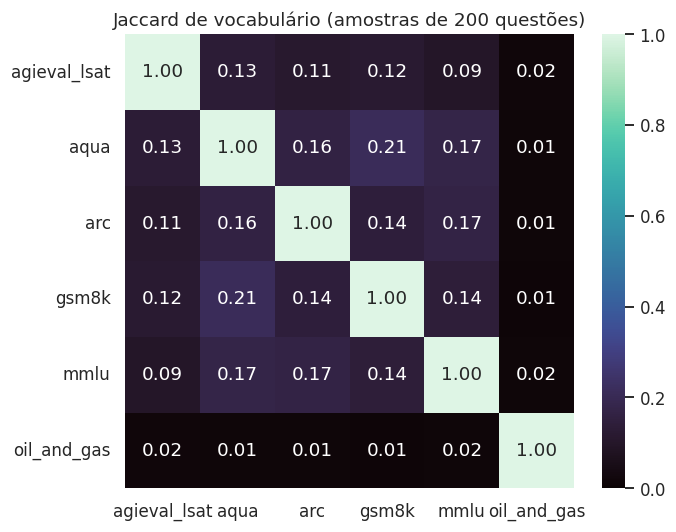

In [7]:
vocabs = {}
for ds, g in all_df.groupby("dataset"):
    samp = g.sample(min(200, len(g)), random_state=42)
    vocabs[ds] = set().union(*samp["q_tokens"])

names = sorted(vocabs)
J = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        J.loc[a, b] = len(vocabs[a] & vocabs[b]) / len(vocabs[a] | vocabs[b])

plt.figure(figsize=(6.5, 5))
sns.heatmap(J.astype(float), annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1)
plt.title("Jaccard de vocabulário (amostras de 200 questões)")
plt.tight_layout(); plt.show()

## 4. Semelhança entre perguntas — clusters

Representação TF-IDF → SVD(50) → t-SNE, com até 300 questões por dataset. **Nota metodológica:** TF-IDF é um proxy léxico rápido para esta análise exploratória; a Fase 3 do pipeline usará *sentence embeddings* (decisão pendente do modelo — ver §7). A estrutura de clusters aqui já indica o quão separáveis são os domínios.

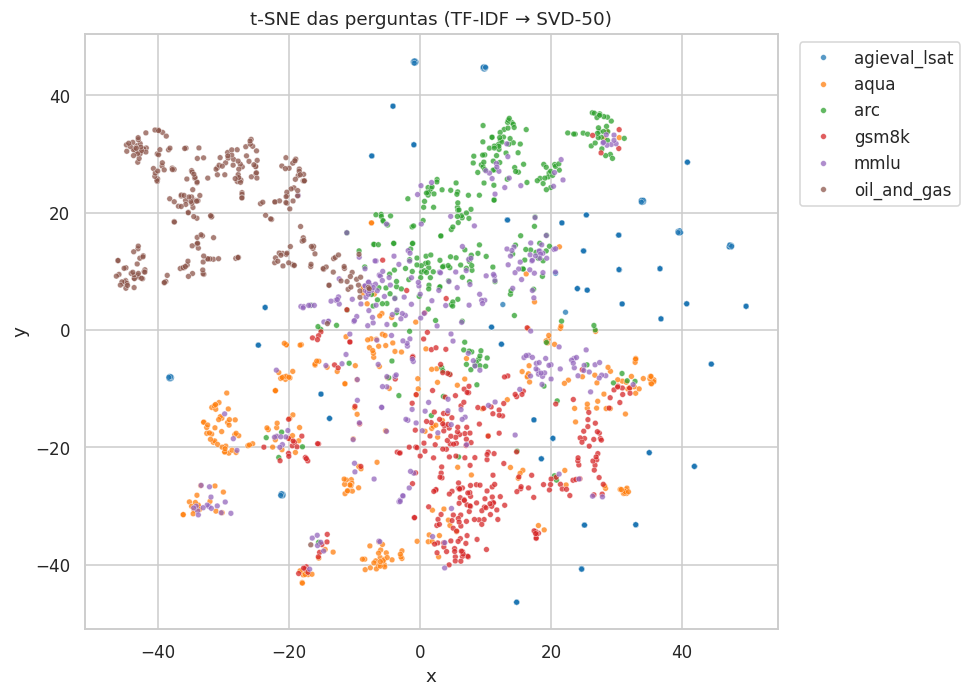

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

sample = (all_df.groupby("dataset", group_keys=False)
          .apply(lambda g: g.sample(min(300, len(g)), random_state=42))
          .reset_index(drop=True))

tfidf = TfidfVectorizer(max_features=20000, sublinear_tf=True, stop_words="english")
X = tfidf.fit_transform(sample["question"])
Xr = TruncatedSVD(n_components=50, random_state=42).fit_transform(X)
XY = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(Xr)
sample["x"], sample["y"] = XY[:, 0], XY[:, 1]

plt.figure(figsize=(9, 6.5))
sns.scatterplot(data=sample, x="x", y="y", hue="dataset", s=14, alpha=0.75, palette="tab10")
plt.title("t-SNE das perguntas (TF-IDF → SVD-50)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

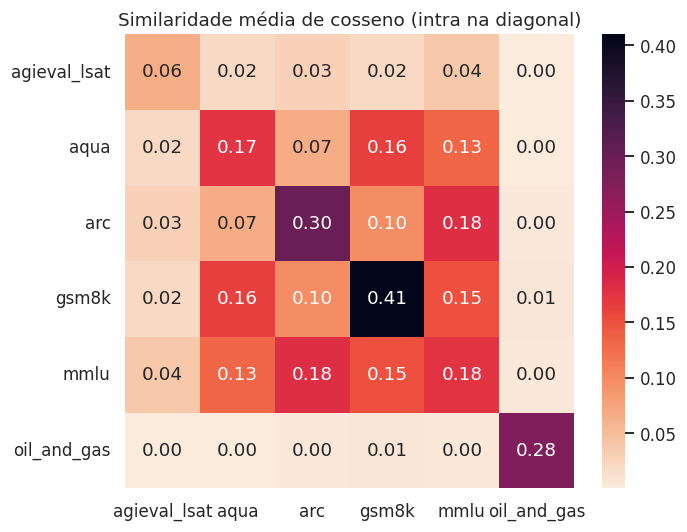

Coesão interna (diagonal):
gsm8k           0.410
arc             0.299
oil_and_gas     0.278
mmlu            0.176
aqua            0.174
agieval_lsat    0.065
dtype: float64


In [9]:
# Similaridade média de cosseno intra e inter-dataset (na base SVD)
sim = cosine_similarity(Xr)
labels = sample["dataset"].values
S = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    ia = np.where(labels == a)[0]
    for b in names:
        ib = np.where(labels == b)[0]
        block = sim[np.ix_(ia, ib)]
        if a == b:
            block = block[~np.eye(len(ia), dtype=bool)]
        S.loc[a, b] = block.mean()

plt.figure(figsize=(6.5, 5))
sns.heatmap(S.astype(float), annot=True, fmt=".2f", cmap="rocket_r")
plt.title("Similaridade média de cosseno (intra na diagonal)")
plt.tight_layout(); plt.show()

print("Coesão interna (diagonal):")
print(pd.Series(np.diag(S.values.astype(float)), index=S.index).round(3).sort_values(ascending=False))

**Leitura:** a diagonal mede a **coesão interna** de cada dataset. Datasets coesos (perguntas parecidas entre si) favorecem a recuperação de reflexões relevantes; datasets dispersos (ex.: MMLU, multidisciplinar) tendem a recuperar reflexões pouco relacionadas — previsão de *Transferability* baixa.

## 5. Viabilidade da recuperação treino→teste (proxy de Transferability)

A Fase 3 injeta no prompt reflexões recuperadas por similaridade semântica (top-k). A pergunta prática: **quão parecida é a questão de teste mais próxima do pool de treino?** Se a similaridade máxima for baixa, a reflexão recuperada dificilmente será útil — independentemente da qualidade da reflexão.

Para datasets **sem pool de treino** (agieval_lsat, mmlu, oil_and_gas) simulamos o split interno proposto na §7.

In [10]:
def get_pools(ds):
    g = all_df[all_df.dataset == ds]
    tr = g[g.split == "train"]
    te = g[g.split == "test"]
    if len(tr) == 0:  # simula split interno 50/50 do teste
        te_all = te.sample(frac=1, random_state=42)
        half = len(te_all) // 2
        tr, te = te_all.iloc[:half], te_all.iloc[half:]
    return tr, te

rows = []
for ds in names:
    tr, te = get_pools(ds)
    tr_s = tr.sample(min(3000, len(tr)), random_state=42)
    te_s = te.sample(min(500, len(te)), random_state=42)
    vec = TfidfVectorizer(max_features=20000, sublinear_tf=True, stop_words="english")
    Xtr = vec.fit_transform(tr_s["question"])
    Xte = vec.transform(te_s["question"])
    simm = cosine_similarity(Xte, Xtr)
    top1 = simm.max(axis=1)
    top5 = np.sort(simm, axis=1)[:, -5:].mean(axis=1)
    rows.append({"dataset": ds, "pool_treino": len(tr), "teste": len(te),
                 "split_simulado": len(tr[tr.split=='train']) == 0 if len(tr) else True,
                 "sim_top1 (média)": top1.mean(), "sim_top1 (mediana)": np.median(top1),
                 "sim_top5 (média)": top5.mean(),
                 "% teste com top1 ≥ 0.3": (top1 >= 0.3).mean()})

retrieval = pd.DataFrame(rows).set_index("dataset").round(3)
retrieval

,pool_treino,teste,split_simulado,sim_top1 (média),sim_top1 (mediana),sim_top5 (média),% teste com top1 ≥ 0.3
dataset,,,,,,,
agieval_lsat,115,115,True,0.987,0.992,0.525,1.000
aqua,97467,254,False,0.413,0.383,0.331,0.752
arc,1119,1172,False,0.375,0.346,0.281,0.630
gsm8k,7473,1319,False,0.354,0.344,0.280,0.662
mmlu,6016,6016,True,0.345,0.297,0.243,0.492
oil_and_gas,1273,1273,True,0.470,0.447,0.357,0.948


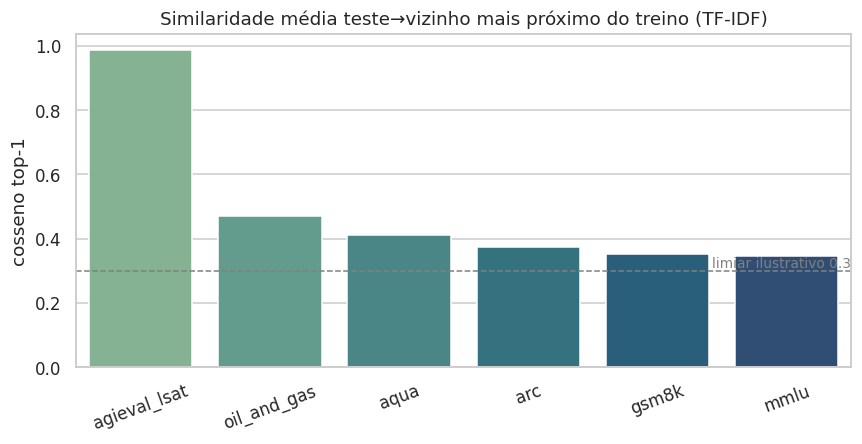

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.2))
r = retrieval.sort_values("sim_top1 (média)", ascending=False)
sns.barplot(x=r.index, y=r["sim_top1 (média)"], palette="crest", ax=ax)
ax.axhline(0.3, ls="--", c="gray", lw=1)
ax.text(len(r)-0.5, 0.31, "limiar ilustrativo 0.3", ha="right", c="gray", fontsize=9)
ax.set(title="Similaridade média teste→vizinho mais próximo do treino (TF-IDF)",
       ylabel="cosseno top-1", xlabel="")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

### ⚠️ Alerta de vazamento: questões que compartilham contexto

O `agieval_lsat` aparece com sim_top1 ≈ 0.99 — **artefato, não coesão real**: questões de LSAT vêm em grupos que compartilham o mesmo enunciado-base (o "jogo" lógico). Um split aleatório por questão coloca perguntas do MESMO jogo em treino e teste → a recuperação encontra um "vizinho" que é quase a mesma questão → mede memorização, exatamente a fragilidade nº 3 do paper original que queremos eliminar. Verificação abaixo; a decisão D1 passa a exigir **split por grupo/contexto**.

In [12]:
for ds in names:
    g = all_df[all_df.dataset == ds]
    pref = g["question"].str[:200]
    print(f"{ds:14s} questões={len(g):6d}  contextos únicos (200 chars)={pref.nunique():6d}"
          f"  máx. questões/contexto={pref.value_counts().iloc[0]}")

agieval_lsat   questões=   233  contextos únicos (200 chars)=    43  máx. questões/contexto=7
aqua           questões= 97975  contextos únicos (200 chars)= 78645  máx. questões/contexto=52
arc            questões=  2590  contextos únicos (200 chars)=  2576  máx. questões/contexto=3
gsm8k          questões=  8792  contextos únicos (200 chars)=  8792  máx. questões/contexto=1
mmlu           questões= 12102  contextos únicos (200 chars)= 11546  máx. questões/contexto=14
oil_and_gas    questões=  2546  contextos únicos (200 chars)=  2540  máx. questões/contexto=2


## 6. Impacto esperado da reflexão por dataset

**Hipótese central da extensão:** reflexão externa ajuda onde o erro é de **processo** (a reflexão codifica correção procedimental transferível entre questões similares) e ajuda pouco onde o erro é de **conhecimento faltante** (refletir não cria o fato que o modelo não sabe).

Cruzamos os proxies medidos com o tipo de raciocínio dominante de cada dataset:

In [13]:
reasoning = {
    "arc":          ("indutivo + conhecimento", "conhecimento"),
    "gsm8k":        ("procedural multi-passo",  "processo"),
    "aqua":         ("procedural/algébrico",    "processo"),
    "agieval_lsat": ("dedutivo (constraints)",  "processo"),
    "mmlu":         ("misto (recall + racioc.)","conhecimento"),
    "oil_and_gas":  ("técnico de domínio",      "conhecimento"),
}

impact = pd.DataFrame({
    "raciocínio dominante": pd.Series({k: v[0] for k, v in reasoning.items()}),
    "tipo de erro esperado": pd.Series({k: v[1] for k, v in reasoning.items()}),
    "densidade numérica": text_stats["densidade numérica"],
    "coesão interna": pd.Series(np.diag(S.values.astype(float)).round(3), index=S.index),
    "sim treino→teste (top1)": retrieval["sim_top1 (média)"],
    "pool de treino": retrieval["pool_treino"],
})

def expectativa(row):
    score = 0
    score += 2 if row["tipo de erro esperado"] == "processo" else 0
    score += 1 if row["sim treino→teste (top1)"] >= impact["sim treino→teste (top1)"].median() else 0
    score += 1 if row["coesão interna"] >= impact["coesão interna"].median() else 0
    return {0: "baixa", 1: "baixa", 2: "média", 3: "alta", 4: "alta"}[score]

impact["impacto esperado da reflexão"] = impact.apply(expectativa, axis=1)
impact.sort_values("impacto esperado da reflexão")

,raciocínio dominante,tipo de erro esperado,densidade numérica,coesão interna,sim treino→teste (top1),pool de treino,impacto esperado da reflexão
agieval_lsat,dedutivo (constraints),processo,0.016,0.065,0.987,115,alta
aqua,procedural/algébrico,processo,0.127,0.174,0.413,97467,alta
gsm8k,procedural multi-passo,processo,0.078,0.410,0.354,7473,alta
arc,indutivo + conhecimento,conhecimento,0.006,0.299,0.375,1119,baixa
mmlu,misto (recall + racioc.),conhecimento,0.063,0.176,0.345,6016,baixa
oil_and_gas,técnico de domínio,conhecimento,0.004,0.278,0.470,1273,média


**Discussão por dataset:**

- **GSM8K / AQuA (impacto esperado: alto).** Erros majoritariamente de processo (aritmética multi-passo, montagem de equação). Reflexões do tipo *instructions/explanation* devem transferir bem entre questões estruturalmente similares — e a densidade numérica alta + coesão interna razoável indicam que a recuperação por similaridade encontra vizinhos úteis. É onde a hipótese prevê o maior ganho. Cuidado: na conversão MCQ do GSM8K, distratores implausíveis podem inflar o baseline de retry.
- **AGIEval LSAT (impacto esperado: médio-alto, mas amostra pequena).** Erros de processo dedutivo (gestão de constraints) — em tese, terreno fértil para reflexão procedural. Porém o pool de treino é pequeno (~115 questões após split **por jogo**, nunca por questão — ver alerta de vazamento na §5), o que limita cobertura da memória; esperar variância alta. Curiosamente, o compartilhamento de contexto vira uma *feature* experimental: reflexões geradas em perguntas do mesmo jogo (se mantidas juntas no treino) testam transferência a curtíssima distância semântica.
- **ARC (impacto esperado: médio-baixo).** Mistura conhecimento científico e raciocínio. É o dataset do paper original — serve de **âncora de comparabilidade**. A previsão da hipótese: o ganho observado no paper (mesma questão) deve **encolher** no protocolo treino→teste, porque parte era memorização.
- **MMLU (impacto esperado: baixo).** Multidisciplinar, recall-intensivo, coesão interna baixa → reflexões recuperadas tendem a vir de tópicos distantes. Resultado negativo aqui **confirma** a hipótese (é contribuição, não fracasso).
- **oil_and_gas (impacto esperado: baixo, mas valor estratégico).** Conhecimento técnico de domínio; reflexão não cria fatos. Porém é o único dataset com `subject`/`difficulty`/`justification` — permite análises condicionais (utility × dificuldade × assunto) que nenhum dos públicos permite, além de ser contribuição de dataset próprio.

**Duas previsões falsificáveis para registrar já:** (1) ordenação de *Reflection Utility*: GSM8K ≈ AQuA > LSAT > ARC > MMLU ≈ oil_and_gas; (2) dentro de qualquer dataset, utility cresce com a similaridade da reflexão recuperada (curva utility × similaridade com inclinação positiva). O *error loop* (resultado mais robusto do paper) deve cair com reflexão externa em **todos** os datasets — essa é a parte que esperamos que generalize.

## 7. Rotas e decisões

### Decisões propostas agora (curto prazo)

| # | Decisão | Proposta | Racional |
|---|---|---|---|
| D1 | Splits | ARC, AQuA e GSM8K: splits oficiais. AGIEval: split **por jogo/contexto** (~24 jogos treino / ~16 teste), nunca por questão (vazamento — §5). MMLU: amostrar 1.000 treino / 500 teste do test set. oil_and_gas: 60/40 estratificado por `subject` | Splits oficiais onde existem (reprodutibilidade); split interno documentado com seed fixa; checar contexto compartilhado em TODOS os datasets antes de congelar |
| D2 | Subamostragem | AQuA treino: 1.000 questões; GSM8K treino: 1.000; teste: até 500/dataset | Custo cresce com \|modelos\|² × \|tipos\| × \|datasets\|; 500 questões dão IC de ±4pp |
| D3 | Baselines obrigatórios | (a) sem reflexão; (b) retry com feedback sem reflexão; (c) self-consistency com orçamento igual; (d) self-reflection (paper) | Fragilidades 1–2 do documento de contexto; revisor vai cobrar |
| D4 | Seeds | 3 runs mínimos, seeds fixas (42, 43, 44), reportar média ± dp + teste de significância | Fragilidade 6 |
| D5 | Memória de reflexões | Por dataset (não compartilhada) na 1ª rodada | Jaccard/similaridade inter-dataset baixos → memória compartilhada só adiciona ruído; testar compartilhada depois como ablação |
| D6 | GSM8K MCQ | Auditar geração dos distratores antes de rodar | Distratores implausíveis inflam retry baseline |

### Decisões pendentes (levar ao orientador)

1. **Modelo de embeddings da Fase 3** — candidatos: `all-MiniLM-L6-v2` (rápido, 384d), `bge-small-en-v1.5`, `nomic-embed-text` (via Ollama, mantém stack local). Critério: correlação com utility, não benchmark genérico.
2. **k da recuperação** — varrer k ∈ {1, 3, 5}; k=0 é o baseline (b).
3. **LLM refletor forte** (substituto do GPT-3.5): Llama-3.3-70B, Qwen2.5-72B ou DeepSeek-V3 — pesa reprodutibilidade aberta.
4. **Incluir oil_and_gas no journal?** Custo extra vs. valor de dataset próprio + análises por dificuldade/assunto.
5. **Journal-alvo** (JAAMAS, TMLR, ACM TIST, Neurocomputing) — define limite de páginas e, portanto, quantos datasets/modelos cabem.

### Rota de longo prazo (próximos notebooks/scripts)

- `02` — auditoria do GSM8K-MCQ (D6) + congelamento dos splits (D1/D2) em arquivos versionados `data/splits/`;
- `03` — Fase 1: respostas dos SLMs no treino (Ollama: phi-2 → phi4-mini → llama3.1:8b), com CoT, temperatura 0;
- `04` — Fase 2: matriz de reflexões (self × cross-model) × (simples × complexa), taxonomia de Renze & Guven;
- `05` — Fase 3: teste com recuperação top-k + baselines D3;
- `06` — métricas: Reflection Utility, Transferability (utility × similaridade), Error Persistence, custo (tokens/chamadas);
- `07` — análises finais, figuras do paper, testes estatísticos.

In [14]:
# Exporta os artefatos da análise para results/
text_stats.to_csv(RESULTS / "01_text_stats.csv")
overview.to_csv(RESULTS / "01_split_overview.csv")
retrieval.to_csv(RESULTS / "01_retrieval_feasibility.csv")
impact.to_csv(RESULTS / "01_reflection_impact_expectation.csv")
J.to_csv(RESULTS / "01_vocab_jaccard.csv")
S.to_csv(RESULTS / "01_semantic_similarity.csv")
print("Artefatos salvos em", RESULTS.resolve())
for f in sorted(RESULTS.glob("01_*.csv")):
    print(" -", f.name)

Artefatos salvos em /sessions/jolly-vigilant-goodall/mnt/eagle/journal_extension/results
 - 01_reflection_impact_expectation.csv
 - 01_retrieval_feasibility.csv
 - 01_semantic_similarity.csv
 - 01_split_overview.csv
 - 01_text_stats.csv
 - 01_vocab_jaccard.csv
